In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import libraries to find mae, mse
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
#read csv file
df = pd.read_csv('student_scores.csv')
#displaying the content in datafile
df.head() 

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [5]:
df.tail()

,Hours,Scores
20,2.7,30
21,4.8,54
22,3.8,35
23,6.9,76
24,7.8,86


In [6]:
# Segregating data to variables
X=df.iloc[:,:-1].values
X

array([[2.5],
       [5.1],
       [3.2],
       [8.5],
       [3.5],
       [1.5],
       [9.2],
       [5.5],
       [8.3],
       [2.7],
       [7.7],
       [5.9],
       [4.5],
       [3.3],
       [1.1],
       [8.9],
       [2.5],
       [1.9],
       [6.1],
       [7.4],
       [2.7],
       [4.8],
       [3.8],
       [6.9],
       [7.8]])

In [7]:
y=df.iloc[:,-1].values
y

array([21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30,
       24, 67, 69, 30, 54, 35, 76, 86])

In [8]:
#splitting train and test data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=1/2,random_state=0)

In [15]:
#implement the Linear Regression Model
def LinearRegression(x, y, X_test):
    x = x.flatten() 
    y = y.flatten() 
    
    n = len(x)
    xy = x * y
    xsq = x * x
    Sx = x.sum()
    Sy = y.sum()
    Sxy = xy.sum()
    Sxsq = xsq.sum()

    denom = (n * Sxsq - Sx * Sx)
    if denom == 0:
        raise ValueError("All x values are the same")

    m = (n * Sxy - Sx * Sy) / denom
    c = y.mean() - m * x.mean()

    return m * X_test.flatten() + c
y_pred = LinearRegression(X_train, y_train, X_test)

In [16]:
#displaying predicted values
y_pred

array([14.97354023, 31.81174713, 73.41202299, 24.87836782, 58.55478161,
       37.75464368, 18.93547126, 77.37395402, 68.4596092 , 11.0116092 ,
       50.63091954, 76.38347126, 32.80222989])

In [17]:
#displaying actual values
y_test

array([20, 27, 69, 30, 62, 35, 24, 86, 76, 17, 47, 85, 42])

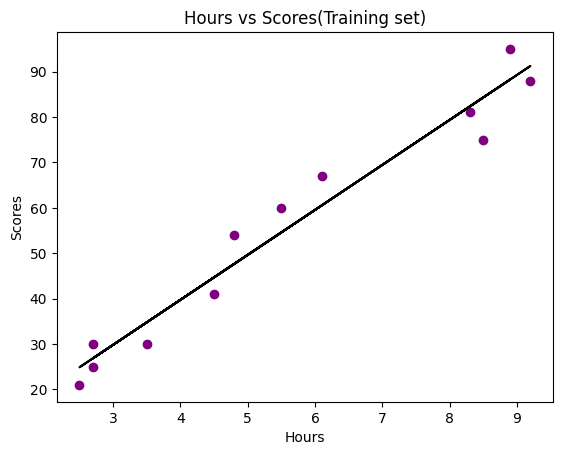

In [21]:
#graph plot for training data
plt.scatter(X_train,y_train,color='purple')
plt.plot(X_train, LinearRegression(X_train, y_train, X_train),color='black')
plt.title("Hours vs Scores(Training set)")
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.show()

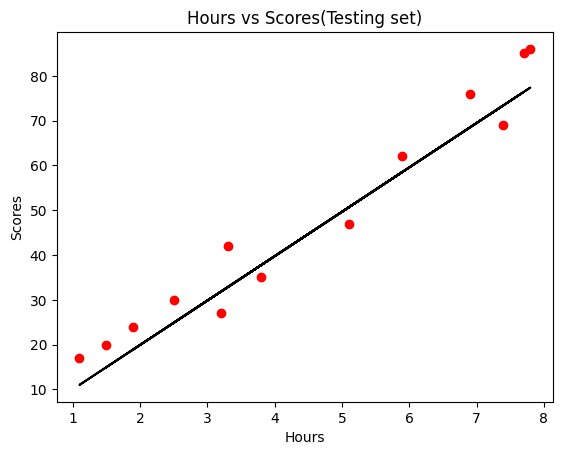

In [24]:
#graph plot for test data
plt.scatter(X_test,y_test,color='red')
plt.plot(X_test,y_pred,color='black')
plt.title("Hours vs Scores(Testing set)")
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.show()

In [25]:
#find mae,mse,rmse
mse=mean_absolute_error(y_test,y_pred)
print('Mean Square Error = ',mse)
mae=mean_absolute_error(y_test,y_pred)
print('Mean Absolute Error = ',mae)
rmse=np.sqrt(mse)
print("Root Mean Square Error = ",rmse)

Mean Square Error =  5.710484526967274
Mean Absolute Error =  5.710484526967274
Root Mean Square Error =  2.389662011031534
